In [25]:
import sys
sys.path.append(r'C:\Users\Sarthak\Documents\ML\fighter-beta\mma\notebooks')
from src.predict import predict_fight

[predict] Loading model and cached data...
[predict] Ready. 3760 fighters loaded.


In [19]:
import pickle
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
from src.features import (
    calculate_three_layer_features_v2,
    calculate_strike_features,
    calculate_r1_features,
    calculate_career_stats,
    parse_reach,
    parse_height,
    parse_age,
    parse_fight_duration,
    time_decay_weights,
    kish_effective_n,
    bayesian_smooth,
    normalize_weight_class
)
#from src.predict import predict_fight
DATA_PATH = r'C:\Users\Sarthak\Documents\ML\fighter-beta\mma\notebooks\02_features\data'
DB_PATH   = r'C:\Users\Sarthak\Documents\ML\fighter-beta\mma_fighters.db'

model                   = pickle.load(open(f'{DATA_PATH}/xgb_best_model.pkl', 'rb'))
feature_cols            = pickle.load(open(f'{DATA_PATH}/feature_cols.pkl', 'rb'))
fighter_fights_dict     = pickle.load(open(f'{DATA_PATH}/fighter_fights_dict.pkl', 'rb'))
opponents_dict          = pickle.load(open(f'{DATA_PATH}/opponents_dict.pkl', 'rb'))
fighter_adjperf_history = pickle.load(open(f'{DATA_PATH}/fighter_adjperf_history.pkl', 'rb'))
all_fight_stats         = pickle.load(open(f'{DATA_PATH}/all_fight_stats.pkl', 'rb'))
conn                    = sqlite3.connect(DB_PATH)

print("✔ All data loaded")
fighter_fights_dict     = pickle.load(open(f'{DATA_PATH}/fighter_fights_dict.pkl', 'rb'))
opponents_dict          = pickle.load(open(f'{DATA_PATH}/opponents_dict.pkl', 'rb'))
fighter_adjperf_history = pickle.load(open(f'{DATA_PATH}/fighter_adjperf_history.pkl', 'rb'))

# DB connection
conn = sqlite3.connect(DB_PATH)

print(f"✔ Model loaded")
print(f"✔ Features: {len(feature_cols)}")
print(f"✔ Fighters cached: {len(fighter_fights_dict)}")

✔ All data loaded
✔ Model loaded
✔ Features: 118
✔ Fighters cached: 3760


In [44]:
f1 = predict_fight("Khamzat Chimaev", "Sean Strickland")
print(f1)

f2 = predict_fight("Joshua Van", "Tatsuro Taira")
print(f2)

f3 = predict_fight("Alexander Volkov", "Waldo Cortes Acosta")
print(f3)

f4 = predict_fight("Sean Brady", "Joaquin Buckley")
print(f4)

f5 = predict_fight("King Green", "Jeremy Stephens")
print(f5)

{'f1': 'Khamzat Chimaev', 'f2': 'Sean Strickland', 'f1_prob': 81.6, 'f2_prob': 18.4, 'pick': 'Khamzat Chimaev', 'confidence': 81.6}
{'f1': 'Joshua Van', 'f2': 'Tatsuro Taira', 'f1_prob': 37.6, 'f2_prob': 62.4, 'pick': 'Tatsuro Taira', 'confidence': 62.4}
{'f1': 'Alexander Volkov', 'f2': 'Waldo Cortes Acosta', 'f1_prob': 56.5, 'f2_prob': 43.5, 'pick': 'Alexander Volkov', 'confidence': 56.5}
{'f1': 'Sean Brady', 'f2': 'Joaquin Buckley', 'f1_prob': 67.8, 'f2_prob': 32.2, 'pick': 'Sean Brady', 'confidence': 67.8}
{'f1': 'King Green', 'f2': 'Jeremy Stephens', 'f1_prob': 67.5, 'f2_prob': 32.5, 'pick': 'King Green', 'confidence': 67.5}


In [45]:
f1 = predict_fight("Ateba Gautier", "Ozzy Diaz")
print(f1)

f2 = predict_fight("Joel Alvarez", "Yaroslav Amosov")
print(f2)

f3 = predict_fight("Grant Dawson", "Mateusz Rebecki")
print(f3)

f4 = predict_fight("Jim Miller", "Jared Gordon")
print(f4)

f5 = predict_fight("Roman Kopylov", "Marco Tulio")
print(f5)

{'f1': 'Ateba Gautier', 'f2': 'Ozzy Diaz', 'f1_prob': 81.3, 'f2_prob': 18.7, 'pick': 'Ateba Gautier', 'confidence': 81.3}
{'f1': 'Joel Alvarez', 'f2': 'Yaroslav Amosov', 'f1_prob': 56.9, 'f2_prob': 43.1, 'pick': 'Joel Alvarez', 'confidence': 56.9}
{'f1': 'Grant Dawson', 'f2': 'Mateusz Rebecki', 'f1_prob': 56.7, 'f2_prob': 43.3, 'pick': 'Grant Dawson', 'confidence': 56.7}
{'f1': 'Jim Miller', 'f2': 'Jared Gordon', 'f1_prob': 50.6, 'f2_prob': 49.4, 'pick': 'Jim Miller', 'confidence': 50.6}
{'f1': 'Roman Kopylov', 'f2': 'Marco Tulio', 'f1_prob': 21.9, 'f2_prob': 78.1, 'pick': 'Marco Tulio', 'confidence': 78.1}


In [46]:
f6 = predict_fight("Pat Sabatini", "William Gomis")
print(f6)

f7 = predict_fight("Baisangur Susurkaev", "Djorden Santos")
print(f7)

{'f1': 'Pat Sabatini', 'f2': 'William Gomis', 'f1_prob': 46.8, 'f2_prob': 53.2, 'pick': 'William Gomis', 'confidence': 53.2}
{'f1': 'Baisangur Susurkaev', 'f2': 'Djorden Santos', 'f1_prob': 71.8, 'f2_prob': 28.2, 'pick': 'Baisangur Susurkaev', 'confidence': 71.8}


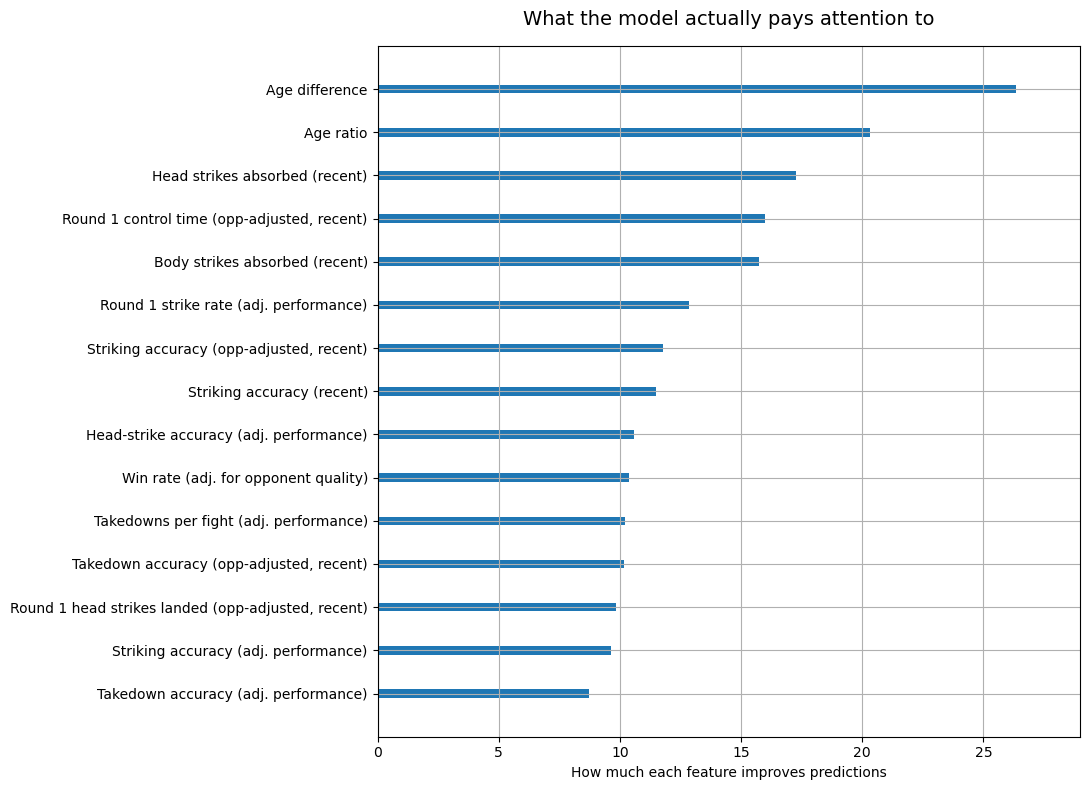

In [4]:
import pickle
import matplotlib.pyplot as plt
from xgboost import plot_importance

DATA_PATH = r'C:\Users\Sarthak\Documents\ML\fighter-beta\mma\notebooks\02_features\data'
model = pickle.load(open(f'{DATA_PATH}/xgb_best_model.pkl', 'rb'))

rename_map = {
    'age_diff': 'Age difference',
    'age_ratio': 'Age ratio',
    'diff_head_allowed_dec_avg': 'Head strikes absorbed (recent)',
    'diff_r1_ctrl_per_min_opp_dec_avg': 'Round 1 control time (opp-adjusted, recent)',
    'diff_body_allowed_dec_avg': 'Body strikes absorbed (recent)',
    'diff_r1_slpm_dec_adjperf': 'Round 1 strike rate (adj. performance)',
    'diff_str_acc_opp_dec_avg': 'Striking accuracy (opp-adjusted, recent)',
    'diff_str_acc_dec_avg': 'Striking accuracy (recent)',
    'diff_head_acc_dec_adjperf': 'Head-strike accuracy (adj. performance)',
    'diff_win_adjperf': 'Win rate (adj. for opponent quality)',
    'diff_td_avg_adjperf': 'Takedowns per fight (adj. performance)',
    'diff_td_acc_opp_dec_avg': 'Takedown accuracy (opp-adjusted, recent)',
    'diff_r1_head_lpm_opp_dec_avg': 'Round 1 head strikes landed (opp-adjusted, recent)',
    'diff_str_acc_dec_adjperf': 'Striking accuracy (adj. performance)',
    'diff_td_acc_dec_adjperf': 'Takedown accuracy (adj. performance)',
}

booster = model.get_booster()
booster.feature_names = [rename_map.get(f, f) for f in booster.feature_names]

fig, ax = plt.subplots(figsize=(11, 8))
plot_importance(
    booster,
    max_num_features=15,
    importance_type='gain',
    ax=ax,
    show_values=False,
    title=None,
    xlabel='How much each feature improves predictions',
    ylabel=None,
)
ax.set_title("What the model actually pays attention to", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import os
DATA_PATH = r'C:\Users\Sarthak\Documents\ML\fighter-beta\mma\notebooks\02_features\data'
total = 0
for f in os.listdir(DATA_PATH):
    size = os.path.getsize(f'{DATA_PATH}/{f}')
    print(f"{f}: {size/1024/1024:.1f} MB")
    total += size
print(f"\nTotal: {total/1024/1024:.1f} MB")

.ipynb_checkpoints: 0.0 MB
adjperf_history.pkl: 3.0 MB
all_fight_stats.pkl: 6.9 MB
feature_cols.pkl: 0.0 MB
fighter_adjperf_history.pkl: 3.5 MB
fighter_fights_dict.pkl: 7.3 MB
fighter_results_dict.pkl: 1.0 MB
fight_decision_dict.pkl: 0.9 MB
fight_features.pkl: 8.6 MB
method_feature_cols.pkl: 0.0 MB
method_label_encoder.pkl: 0.0 MB
method_model.pkl: 0.4 MB
opponents_dict.pkl: 1.3 MB
r1_stats_dict.pkl: 10.4 MB
strike_breakdown.pkl: 6.1 MB
strike_breakdown_dict.pkl: 6.9 MB
strike_defense_dict.pkl: 2.7 MB
xgb_best_model.pkl: 0.1 MB

Total: 59.0 MB


In [6]:
python -c "import flask, pandas, numpy, sklearn, xgboost; print(flask.__version__, pandas.__version__, numpy.__version__, sklearn.__version__, xgboost.__version__)"

SyntaxError: invalid syntax (1518713445.py, line 1)